<a href="https://colab.research.google.com/github/scxbbard/Machine-Learning_101/blob/main/Lin_reg_assump.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats
import statsmodels.stats.api as sms

In [40]:
df = sns.load_dataset("iris")

In [41]:
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [42]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [43]:
df.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [44]:
df.shape

(150, 5)

In [45]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [46]:
df.describe(include="object")

,species
count,150
unique,3
top,setosa
freq,50


In [47]:
df.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


In [48]:
df.drop("species", axis=1, inplace=True)

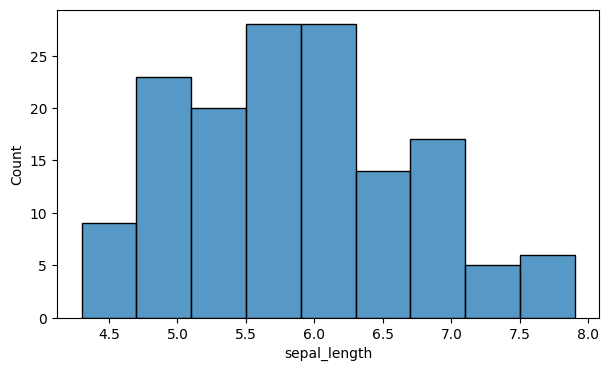

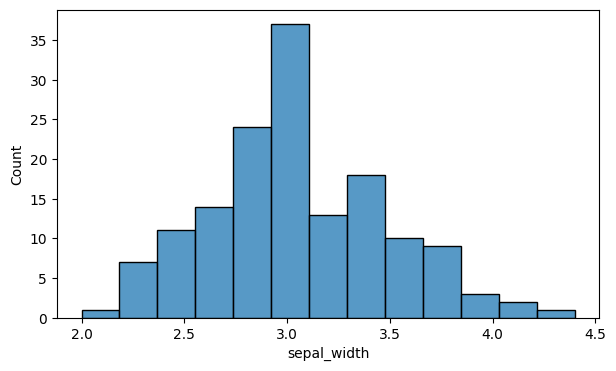

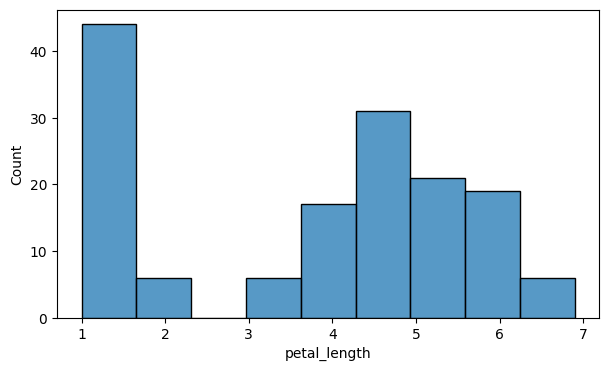

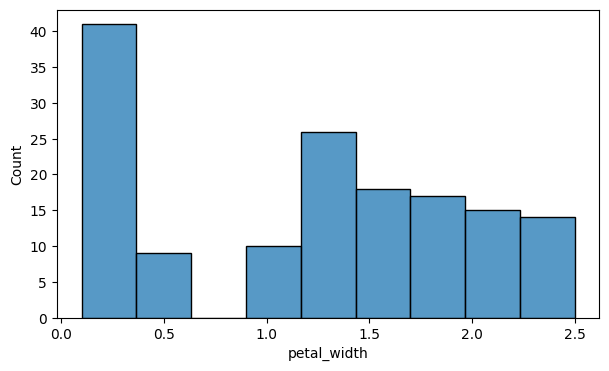

In [49]:
for i in df.columns:
    plt.figure(figsize=(7, 4))
    sns.histplot(data=df, x=i)
    plt.show()

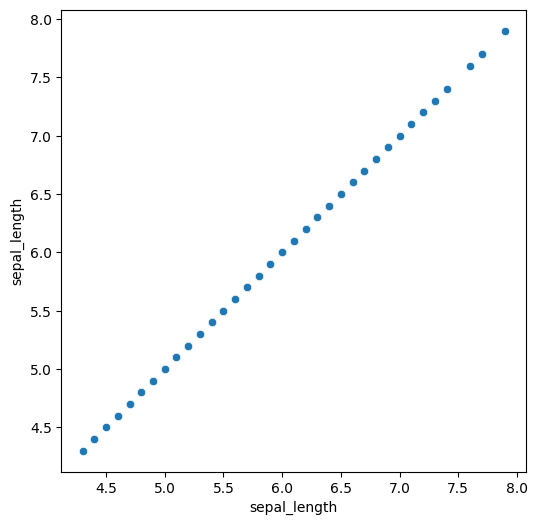

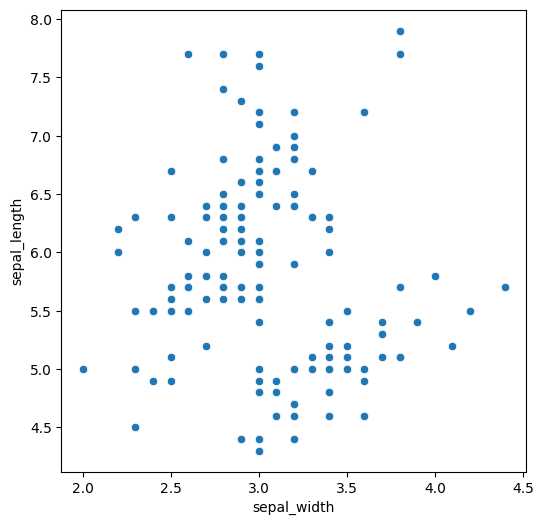

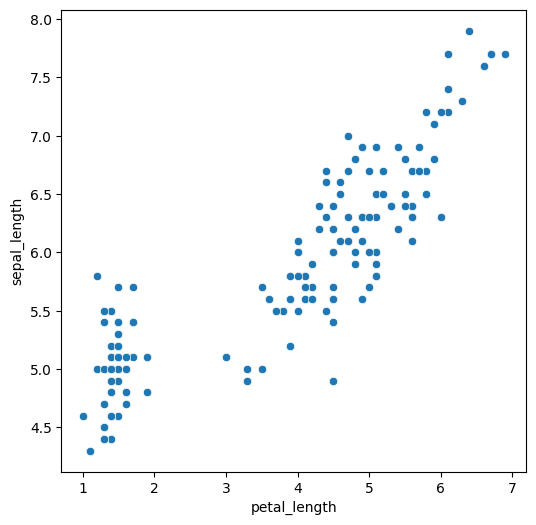

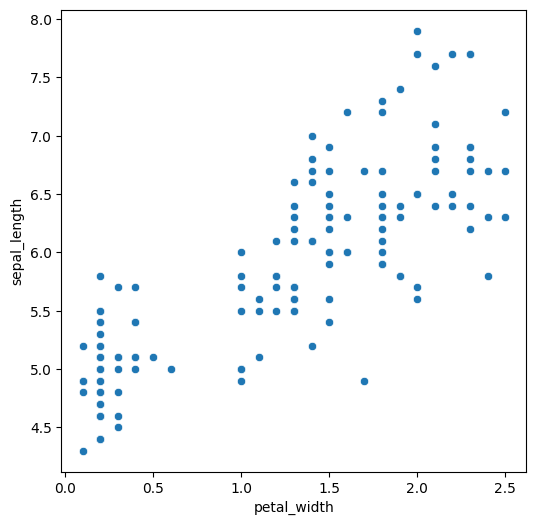

In [50]:
for i in df.columns:
    plt.figure(figsize=(6, 6))
    sns.scatterplot(data=df, x=i, y="sepal_length")
    plt.show()

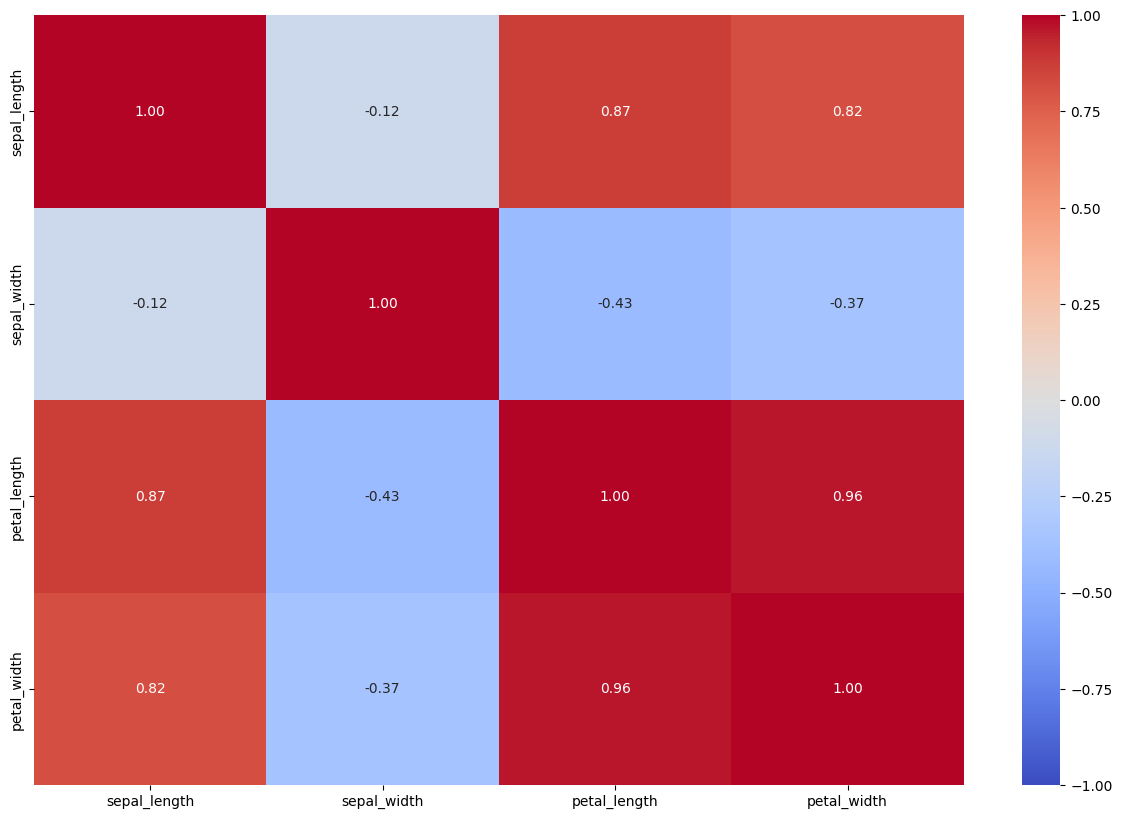

In [51]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="coolwarm")
plt.show()

###**Splitting data**

In [52]:
X = df.drop('sepal_length', axis=1)
y = df['sepal_length']

#Constant term
X = sm.add_constant(X)

###Why do we need a constant term??

###**Model building**
Make the linear model using statsmodels OLS and print the model summary.

In [53]:
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           sepal_length   R-squared:                       0.859
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     295.5
Date:                Wed, 29 Apr 2026   Prob (F-statistic):           8.59e-62
Time:                        15:13:19   Log-Likelihood:                -37.321
No. Observations:                 150   AIC:                             82.64
Df Residuals:                     146   BIC:                             94.69
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            1.8560      0.251      7.401   

###**Assumptions**

In [64]:
fitted = model.fittedvalues
resids = model.resid
stand_resids = model.get_influence().resid_studentized_internal

results_df = pd.DataFrame({
    "Fitted": fitted,
    "Residuals": resids,
    "Studentized Residuals": stand_resids
})

display(results_df.head())

,Fitted,Residuals,Studentized Residuals
0,5.015416,0.084584,0.271705
1,4.689997,0.210003,0.675353
2,4.749251,-0.049251,-0.158205
3,4.825994,-0.225994,-0.725613
4,5.080499,-0.080499,-0.258881


###**Test for linearity**

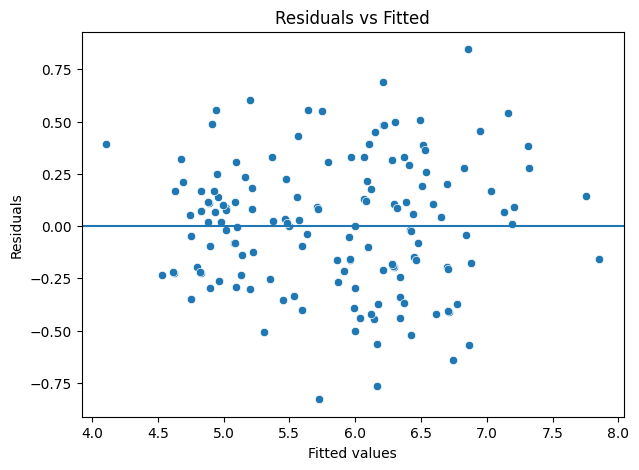

What to look for: random scatter around 0 (no curve/pattern).


In [61]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=resids)
plt.axhline(0)
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

print("What to look for: random scatter around 0 (no curve/pattern).")

###**Test for autocorrlinearity**

In [63]:
from statsmodels.stats.stattools import durbin_watson

# Calculate Durbin-Watson statistic
dw_stat = durbin_watson(resids)

print("Durbin-Watson statistic:", round(dw_stat, 3))

# Interpretation
if dw_stat < 1.5:
    print("Conclusion: Possible positive autocorrelation.")
elif dw_stat > 2.5:
    print("Conclusion: Possible negative autocorrelation.")
else:
    print("Conclusion: No strong evidence of autocorrelation.")

Durbin-Watson statistic: 2.06
Conclusion: No strong evidence of autocorrelation.


###**Test for normality**

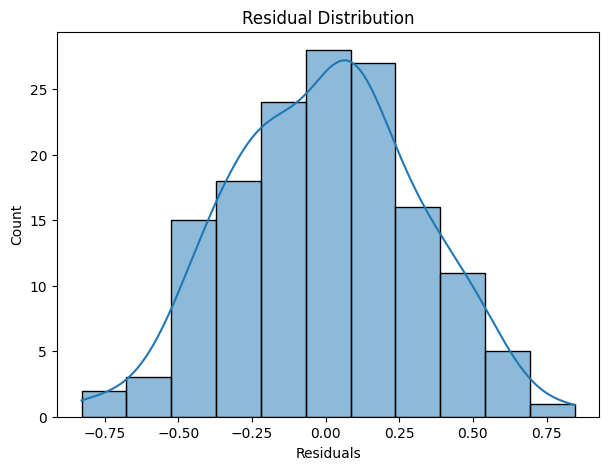

In [65]:
plt.figure(figsize=(7,5))
sns.histplot(resids, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residuals")
plt.show()

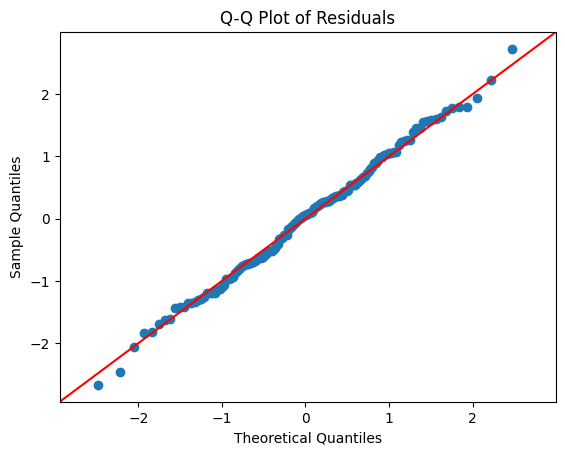

In [67]:
# Q-Q plot
sm.qqplot(resids, line='45', fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

In [68]:
#Shapiro-Wilk test for normality
stats.shapiro(resids)

ShapiroResult(statistic=np.float64(0.9955914223680571), pvalue=np.float64(0.9349086404927768))

###**Test for homoscedasticity**

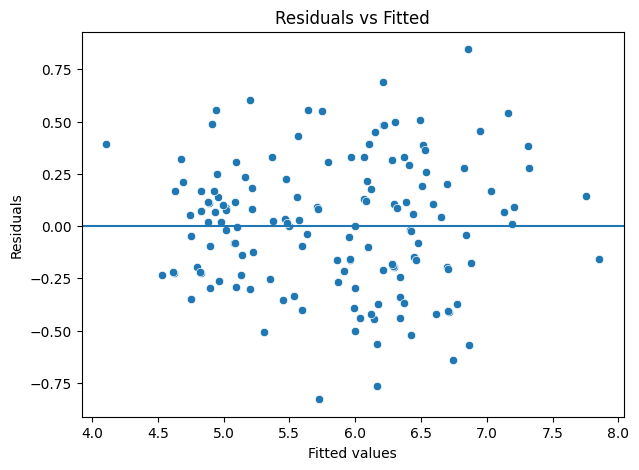

What to look for: no funnel shape (variance should be constant across fitted values).


In [70]:
plt.figure(figsize=(7,5))
sns.scatterplot(x=fitted, y=resids)
plt.axhline(0)
plt.title("Residuals vs Fitted")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.show()

print("What to look for: no funnel shape (variance should be constant across fitted values).")


###**Test for multicollinearity**

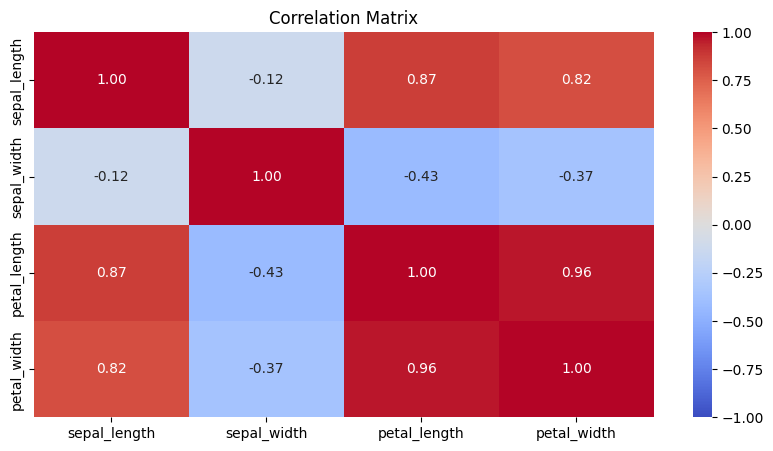

In [73]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix")
plt.show()